<a href="https://colab.research.google.com/github/polazzoza/INFO648/blob/main/FinalProject/INFO_648_Summer_26_Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Phase 1[a]: Business Underst[a]nding

The Department of Economic Development has tasked us with predicting the growth of neighborhoods in a certain area of the United States in order to figure out how to use and allocate it's funding. Our task is to create a model that will be able to predict the growth of states from 2020-2030, so that the Department will be able to allocate funds, and so that neighborhoods will have the allocation of resources necessary for those neighborhoods to succeed and to have the support/infastructure that they need.

Success Criterion:

An AUC of .8 or above would be considered a success when it come to being able to track the growth of neighborhoods at different levels. An AUC of .7 or above would be acceptable but not ideal.

Target:

Our target here is growth between 2020-2030. Did it grow or did it not grow? Will the model think that the population 10 years from the now, with the data that we currently have, will be higher or lower than where it is now? This target is a binary (yes/no), and a classification target.  All the model will need to do is guess between these binary options.

Importing

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import plotly.graph_objects as go
from sklearn import preprocessing
import plotly.graph_objects as go
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error, root_mean_squared_error


In [2]:
#Here is all the data for the project
sd=pd.read_csv('/content/student_tracts_raw (1).csv')
dd=pd.read_csv('/content/data_dictionary.csv')
ft=pd.read_csv('/content/forecast_tracts_2020.csv')
rt=pd.read_csv('/content/region_tract_counts.csv')




#Phase 2[b]: Data Understanding

The Target Region is New England.

*   There are a total of 6 states within New England: Connecticut, Maine, Massachusetts, New Hampshire, Rhode Island, Vermont
*   There is a total of 3392 tracts in the New England data




Exploratory Analysis

In [3]:
#Filtering the data to remove tracts/rows that don't contain one of the 6 NE states
ne_states = ['Connecticut', 'Maine', 'Massachusetts', 'New Hampshire', 'Rhode Island', 'Vermont']
ne = sd[sd['STATE'].isin(ne_states)]

print(f"Original Amount of Tracts in Data: {sd.shape}")
print(f"Filtered Amount of Tracks: {ne.shape}")
display(ne.head(10))

Original Amount of Tracts in Data: (73057, 49)
Filtered Amount of Tracks: (3392, 49)


,GISJOIN,STATE,STATEA,COUNTY,COUNTYA,TRACTA,pop_total_2010,housing_occupied_2010,housing_vacant_2010,housing_owner_occ_2010,...,race_hispwhite_2010,race_hispblack_2010,race_hispaian_2010,race_hispapi_2010,race_hispother_2010,race_hisptwo_2010,pop_total_2020,land_area_sqkm,density_perkm2,settlement_type
12866,G0900010010101,Connecticut,9,Fairfield County,1,10101,4476,1514,264,1278,...,163,2,1,2,23,6,4401.0,32.747439,136.682444,suburban
12867,G0900010010102,Connecticut,9,Fairfield County,1,10102,4330,1418,235,1276,...,187,3,1,1,17,7,4276.0,32.581821,132.896194,suburban
12868,G0900010010201,Connecticut,9,Fairfield County,1,10201,3421,1030,126,848,...,153,0,0,2,31,3,3395.0,11.253122,304.004524,suburban
12869,G0900010010202,Connecticut,9,Fairfield County,1,10202,5359,1876,128,1441,...,346,3,3,0,47,19,5523.0,9.741256,550.134397,suburban
12870,G0900010010300,Connecticut,9,Fairfield County,1,10300,4010,1451,264,1057,...,144,2,0,0,14,12,4305.0,9.607989,417.361011,suburban
12871,G0900010010400,Connecticut,9,Fairfield County,1,10400,5290,2163,180,1493,...,382,11,13,1,142,50,5716.0,2.698094,1960.643328,urban
12872,G0900010010500,Connecticut,9,Fairfield County,1,10500,5494,2408,316,669,...,736,21,3,12,323,78,6005.0,1.816656,3024.237940,urban
12873,G0900010010600,Connecticut,9,Fairfield County,1,10600,1845,1085,167,406,...,179,6,5,1,24,20,1884.0,0.883182,2089.037141,urban
12874,G0900010010700,Connecticut,9,Fairfield County,1,10700,3579,1702,171,864,...,366,7,1,0,82,14,3573.0,1.855238,1929.132543,urban
12875,G0900010010800,Connecticut,9,Fairfield County,1,10800,3388,1350,84,951,...,173,5,0,0,30,10,3516.0,1.945195,1741.727693,urban


In [4]:
#creating a new collumn to show if there was growth between 2020 and 2010
ne['growth']=((ne['pop_total_2020']-ne['pop_total_2010'])/ne['pop_total_2010']>0).astype(int)
ne['growth_pct'] = ((ne['pop_total_2020'] - ne['pop_total_2010']) / ne['pop_total_2010'])*100

ne

/tmp/ipykernel_8448/117205988.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ne['growth']=((ne['pop_total_2020']-ne['pop_total_2010'])/ne['pop_total_2010']>0).astype(int)
/tmp/ipykernel_8448/117205988.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ne['growth_pct'] = ((ne['pop_total_2020'] - ne['pop_total_2010']) / ne['pop_total_2010'])*100


,GISJOIN,STATE,STATEA,COUNTY,COUNTYA,TRACTA,pop_total_2010,housing_occupied_2010,housing_vacant_2010,housing_owner_occ_2010,...,race_hispaian_2010,race_hispapi_2010,race_hispother_2010,race_hisptwo_2010,pop_total_2020,land_area_sqkm,density_perkm2,settlement_type,growth,growth_pct
12866,G0900010010101,Connecticut,9,Fairfield County,1,10101,4476,1514,264,1278,...,1,2,23,6,4401.00,32.747439,136.682444,suburban,0,-1.675603
12867,G0900010010102,Connecticut,9,Fairfield County,1,10102,4330,1418,235,1276,...,1,1,17,7,4276.00,32.581821,132.896194,suburban,0,-1.247113
12868,G0900010010201,Connecticut,9,Fairfield County,1,10201,3421,1030,126,848,...,0,2,31,3,3395.00,11.253122,304.004524,suburban,0,-0.760012
12869,G0900010010202,Connecticut,9,Fairfield County,1,10202,5359,1876,128,1441,...,3,0,47,19,5523.00,9.741256,550.134397,suburban,1,3.060272
12870,G0900010010300,Connecticut,9,Fairfield County,1,10300,4010,1451,264,1057,...,0,0,14,12,4305.00,9.607989,417.361011,suburban,1,7.356608
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67662,G5000270966200,Vermont,50,Windsor County,27,966200,1611,688,377,569,...,0,0,2,4,1621.02,114.280649,14.096875,rural,1,0.621974
67663,G5000270966300,Vermont,50,Windsor County,27,966300,1963,930,2355,611,...,0,1,0,2,2172.00,91.111072,21.545131,rural,1,10.646969
67664,G5000270966500,Vermont,50,Windsor County,27,966500,4187,1882,884,1440,...,0,0,3,9,4196.02,309.163886,13.542979,rural,1,0.215429
67665,G5000270966600,Vermont,50,Windsor County,27,966600,5075,2178,245,1440,...,2,1,12,11,5001.35,69.917019,72.586047,rural,0,-1.451232


In [5]:
#Gemini helped with the code here.
#Have to drop all growths of 0
#I was a little suprised about
#how it did it, cause it was looking was as not a 0, rather than looking for 0s.

initial_rows = ne.shape[0]
ne = ne[ne['growth_pct'] != 0]
print(f"Dropped {initial_rows - ne.shape[0]} rows where growth_pct was 0.")
print(f"New number of rows in 'ne' DataFrame: {ne.shape[0]}")

Dropped 5 rows where growth_pct was 0.
New number of rows in 'ne' DataFrame: 3387


Class Balance

In [6]:
#counts the amount of tracts that are one of the three unique settlements types
settlement_count = ne['settlement_type'].value_counts()
print(settlement_count)

settlement_type
urban       1382
suburban    1301
rural        682
Name: count, dtype: int64


Here is the breakdown of of which settlement types are tracked the most in this data.

Urban:       1382

Suburban:    1301

Rural:        682



The shape aligns with with the region file for tracts

Missing Data

In [7]:
#Gemini helped with the code here

# Calculate the count of missing values for each column
missing_data_counts1 = ne.isnull().sum()

# Display columns with missing data (if any)
# Filtering to show only columns with at least one missing value
missing_data_counts = missing_data_counts1[missing_data_counts1 > 0]

if not missing_data_counts1.empty:
    print("Count of missing data for each column:")
    display(missing_data_counts1)
else:
    print("No missing data found.")

Count of missing data for each column:


,0
GISJOIN,0
STATE,0
STATEA,0
COUNTY,0
COUNTYA,0
TRACTA,0
pop_total_2010,0
housing_occupied_2010,0
housing_vacant_2010,0
housing_owner_occ_2010,0


There is missing data, specifically in land_area_sqkm (21 enteries), density_perkm2 (22 enteries), settlement_type (22 enteries). settlement_type is the only categorical data with any missing data

Here was a little question I was thinking about. Should I have kept in the 22 columns of wetland for the non-categorical data and just set them to 0? That's what I was thinking about doing initially, but it is probably better to be consistent. Maybe? You can't use it, so it's still techinically useful data for potential growth right?

Initial Growth Documentation


In [8]:
#Checking generally how much growth there was
start_growth = ne['growth'].value_counts()
print(start_growth)

growth
1    2430
0     957
Name: count, dtype: int64


In [9]:
#Gemini helped here. Mainly adding the groupby
#Finds growth for each settlement type

growth_by_settlement = ne.groupby('settlement_type')['growth'].value_counts()
print(growth_by_settlement)

settlement_type  growth
rural            1          372
                 0          310
suburban         1          938
                 0          363
urban            1         1119
                 0          263
Name: count, dtype: int64


Rural is split close to evenly, Suburban favors growth almost 3:1 (in favor of growth), and Urban is massively favoring growth.

In [10]:
#Checking the growth per individual state

growth_by_state = ne.groupby('STATE')['growth'].value_counts()
print(growth_by_state)

STATE          growth
Connecticut    1          424
               0          406
Maine          1          207
               0          151
Massachusetts  1         1270
               0          206
New Hampshire  1          232
               0           63
Rhode Island   1          195
               0           49
Vermont        1          102
               0           82
Name: count, dtype: int64


The most growth was seen in Massachusetts, New Hampshire, and Rhode Island. Maine, Vermont, and Connecticut all slightly favor having more growth, but are all split pretty evenly.

#Phase 3[c]: Data Preparation

In [11]:
#The data doesn't need some collumns in here
ne=ne.drop(columns=['GISJOIN', 'STATEA', 'COUNTY', 'COUNTYA', 'TRACTA'])

Undefined-Calculation Cases

In [12]:
#making sure all waterland is removed by setting nans in settlement to 0
ne['settlement_type'] = ne['settlement_type'].fillna(0)

In [13]:
#Rewrote gemini code from earlier to work for this.
#Dropping when settlement type is 0 because it is waterland

initial_rows_st = ne.shape[0]
ne = ne[ne['settlement_type'] != 0]
print(f"Dropped {initial_rows_st - ne.shape[0]} rows where settlement_type was 0.")
print(f"New number of rows in 'ne' DataFrame: {ne.shape[0]}")

Dropped 22 rows where settlement_type was 0.
New number of rows in 'ne' DataFrame: 3365


In [14]:
#Gemini code again
#Checking to see if that is all the NAs using the code from earlier
missing_data_counts2 = ne.isnull().sum()

# Display columns with missing data (if any)
# Filtering to show only columns with at least one missing value
missing_data_counts = missing_data_counts2[missing_data_counts2 > 0]

if not missing_data_counts2.empty:
    print("Count of missing data for each column:")
    display(missing_data_counts2)
else:
    print("No missing data found.")

Count of missing data for each column:


,0
STATE,0
pop_total_2010,0
housing_occupied_2010,0
housing_vacant_2010,0
housing_owner_occ_2010,0
housing_renter_occ_2010,0
age_under5_2010,0
age_5to9_2010,0
age_10to14_2010,0
age_15to17_2010,0


In [15]:
#It was all the NAs so data should have no NAs now
#Think it's alright that growth_pct has 5 nans as it's 0 people living in
#that area, but still rural


In [16]:
#new Variable for encoding and processing
encode_ne=ne.copy()
#looking back on code, never actually used this but it's still here

#Phase 4[d]: Mo[d]eling

K-Means

In [17]:
#Removing Pop_total_2020 and growth_pct to prevent leakage.
new_ne=ne.drop(columns=['pop_total_2020', 'growth_pct'], axis = 1)

In [18]:
new_ne.head(10)

,STATE,pop_total_2010,housing_occupied_2010,housing_vacant_2010,housing_owner_occ_2010,housing_renter_occ_2010,age_under5_2010,age_5to9_2010,age_10to14_2010,age_15to17_2010,...,race_hispwhite_2010,race_hispblack_2010,race_hispaian_2010,race_hispapi_2010,race_hispother_2010,race_hisptwo_2010,land_area_sqkm,density_perkm2,settlement_type,growth
12866,Connecticut,4476,1514,264,1278,236,206,302,367,230,...,163,2,1,2,23,6,32.747439,136.682444,suburban,0
12867,Connecticut,4330,1418,235,1276,142,187,398,453,310,...,187,3,1,1,17,7,32.581821,132.896194,suburban,0
12868,Connecticut,3421,1030,126,848,182,164,297,350,230,...,153,0,0,2,31,3,11.253122,304.004524,suburban,0
12869,Connecticut,5359,1876,128,1441,435,350,469,450,261,...,346,3,3,0,47,19,9.741256,550.134397,suburban,1
12870,Connecticut,4010,1451,264,1057,394,212,302,391,248,...,144,2,0,0,14,12,9.607989,417.361011,suburban,1
12871,Connecticut,5290,2163,180,1493,670,320,295,293,201,...,382,11,13,1,142,50,2.698094,1960.643328,urban,1
12872,Connecticut,5494,2408,316,669,1739,353,265,314,193,...,736,21,3,12,323,78,1.816656,3024.237940,urban,1
12873,Connecticut,1845,1085,167,406,679,68,60,49,29,...,179,6,5,1,24,20,0.883182,2089.037141,urban,1
12874,Connecticut,3579,1702,171,864,838,215,200,219,117,...,366,7,1,0,82,14,1.855238,1929.132543,urban,0
12875,Connecticut,3388,1350,84,951,399,256,268,239,150,...,173,5,0,0,30,10,1.945195,1741.727693,urban,1


In [19]:
#Let's make our test train Split here

In [20]:
X=new_ne.drop(columns=['growth'])
y=new_ne['growth']

In [21]:
X

,STATE,pop_total_2010,housing_occupied_2010,housing_vacant_2010,housing_owner_occ_2010,housing_renter_occ_2010,age_under5_2010,age_5to9_2010,age_10to14_2010,age_15to17_2010,...,race_nhtwo_2010,race_hispwhite_2010,race_hispblack_2010,race_hispaian_2010,race_hispapi_2010,race_hispother_2010,race_hisptwo_2010,land_area_sqkm,density_perkm2,settlement_type
12866,Connecticut,4476,1514,264,1278,236,206,302,367,230,...,31,163,2,1,2,23,6,32.747439,136.682444,suburban
12867,Connecticut,4330,1418,235,1276,142,187,398,453,310,...,45,187,3,1,1,17,7,32.581821,132.896194,suburban
12868,Connecticut,3421,1030,126,848,182,164,297,350,230,...,58,153,0,0,2,31,3,11.253122,304.004524,suburban
12869,Connecticut,5359,1876,128,1441,435,350,469,450,261,...,111,346,3,3,0,47,19,9.741256,550.134397,suburban
12870,Connecticut,4010,1451,264,1057,394,212,302,391,248,...,46,144,2,0,0,14,12,9.607989,417.361011,suburban
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67662,Vermont,1611,688,377,569,119,61,80,110,71,...,22,21,0,0,0,2,4,114.280649,14.096875,rural
67663,Vermont,1963,930,2355,611,319,76,82,97,74,...,37,12,0,0,1,0,2,91.111072,21.545131,rural
67664,Vermont,4187,1882,884,1440,442,168,217,241,154,...,38,25,0,0,0,3,9,309.163886,13.542979,rural
67665,Vermont,5075,2178,245,1440,738,329,297,282,195,...,68,57,0,2,1,12,11,69.917019,72.586047,rural


In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [23]:
X

,STATE,pop_total_2010,housing_occupied_2010,housing_vacant_2010,housing_owner_occ_2010,housing_renter_occ_2010,age_under5_2010,age_5to9_2010,age_10to14_2010,age_15to17_2010,...,race_nhtwo_2010,race_hispwhite_2010,race_hispblack_2010,race_hispaian_2010,race_hispapi_2010,race_hispother_2010,race_hisptwo_2010,land_area_sqkm,density_perkm2,settlement_type
12866,Connecticut,4476,1514,264,1278,236,206,302,367,230,...,31,163,2,1,2,23,6,32.747439,136.682444,suburban
12867,Connecticut,4330,1418,235,1276,142,187,398,453,310,...,45,187,3,1,1,17,7,32.581821,132.896194,suburban
12868,Connecticut,3421,1030,126,848,182,164,297,350,230,...,58,153,0,0,2,31,3,11.253122,304.004524,suburban
12869,Connecticut,5359,1876,128,1441,435,350,469,450,261,...,111,346,3,3,0,47,19,9.741256,550.134397,suburban
12870,Connecticut,4010,1451,264,1057,394,212,302,391,248,...,46,144,2,0,0,14,12,9.607989,417.361011,suburban
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67662,Vermont,1611,688,377,569,119,61,80,110,71,...,22,21,0,0,0,2,4,114.280649,14.096875,rural
67663,Vermont,1963,930,2355,611,319,76,82,97,74,...,37,12,0,0,1,0,2,91.111072,21.545131,rural
67664,Vermont,4187,1882,884,1440,442,168,217,241,154,...,38,25,0,0,0,3,9,309.163886,13.542979,rural
67665,Vermont,5075,2178,245,1440,738,329,297,282,195,...,68,57,0,2,1,12,11,69.917019,72.586047,rural


In [24]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(2692, 43)
(673, 43)
(2692,)
(673,)


In [25]:
#using X_train_K  to train the K means since categoricals can't be
#used for k means. Will move clusters back into trains after
#BTW about to hard-code this in an incredibly annoying way
#Sorry for the mess your about to see
X_train_K=X_train.drop(columns=['STATE','settlement_type'])
X_test_K=X_test.drop(columns=['STATE','settlement_type'])

In [26]:
X_train_K.head(10)

,pop_total_2010,housing_occupied_2010,housing_vacant_2010,housing_owner_occ_2010,housing_renter_occ_2010,age_under5_2010,age_5to9_2010,age_10to14_2010,age_15to17_2010,age_18to19_2010,...,race_nhother_2010,race_nhtwo_2010,race_hispwhite_2010,race_hispblack_2010,race_hispaian_2010,race_hispapi_2010,race_hispother_2010,race_hisptwo_2010,land_area_sqkm,density_perkm2
32540,2149,778,31,691,87,91,145,189,102,61,...,9,24,61,2,0,0,16,13,5.484847,391.806736
13546,1969,630,263,161,469,188,155,179,130,73,...,21,66,327,73,6,0,480,53,0.486841,4044.441614
58794,4665,1862,984,1611,251,222,259,292,177,99,...,3,66,45,2,8,0,22,11,69.963764,66.677373
29464,2708,1175,55,954,221,137,136,143,96,42,...,0,21,11,2,0,0,8,3,26.187744,103.407151
29626,6656,2299,179,1558,741,252,188,261,157,754,...,6,120,80,4,1,1,31,9,24.078469,276.429535
32006,4697,1791,68,1438,353,257,349,353,248,83,...,13,59,109,5,0,0,10,12,5.952491,789.081411
32000,3462,1226,56,1043,183,193,288,377,197,46,...,18,62,46,0,0,2,10,3,6.165184,561.540418
67517,3399,1419,75,454,965,228,226,175,111,90,...,7,117,38,18,2,0,9,17,5.662073,600.310169
13607,4496,1806,100,1529,277,285,248,272,183,78,...,2,161,100,9,5,6,22,37,22.150365,202.976339
32610,3240,1283,89,732,551,204,184,191,128,69,...,56,73,147,27,17,0,164,39,1.715783,1888.350683


In [27]:
#__________________

In [28]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', MinMaxScaler(), X_train_K.columns.tolist()) # Use columns from the K-Means training features
    ]
)

preprocessor1 = ColumnTransformer(
    transformers=[
        ('num1', MinMaxScaler(), X_test_K.columns.tolist()) # Use columns from the K-Means training features
    ]
)

In [29]:
pipeline = Pipeline([
    ('prep', preprocessor),
    ('cluster', KMeans(n_clusters=5, random_state=42, n_init=20))
])
# Fit the pipeline ONLY on the K-Means training features
pipeline.fit(X_train_K)

pipeline1 = Pipeline([
    ('prep1', preprocessor1),
    ('cluster1', KMeans(n_clusters=5, random_state=42, n_init=20))
])
# Fit the pipeline ONLY on the K-Means training features
pipeline1.fit(X_test_K)

Pipeline(steps=[('prep1',
                 ColumnTransformer(transformers=[('num1', MinMaxScaler(),
                                                  ['pop_total_2010',
                                                   'housing_occupied_2010',
                                                   'housing_vacant_2010',
                                                   'housing_owner_occ_2010',
                                                   'housing_renter_occ_2010',
                                                   'age_under5_2010',
                                                   'age_5to9_2010',
                                                   'age_10to14_2010',
                                                   'age_15to17_2010',
                                                   'age_18to19_2010',
                                                   'age_20_2010', 'age_21_2010',
                                                   'age_22to24_2010',
                                                   'age_25to29_2010',
                                                   'ag...010',
                                                   'age_35to39_2010',
                                                   'age_40to44_2010',
                                                   'age_45to49_2010',
                                                   'age_50to54_2010',
                                                   'age_55to59_2010',
                                                   'age_60to61_2010',
                                                   'age_62to64_2010',
                                                   'age_65to69_2010',
                                                   'age_70to74_2010',
                                                   'age_75to79_2010',
                                                   'age_80to84_2010',
                                                   'age_85plus_2010',
                                                   'race_nhwhite_2010',
                                                   'race_nhblack_2010',
                                                   'race_nhaian_2010', ...])])),
                ('cluster1', KMeans(n_clusters=5, n_init=20, random_state=42))])

In [30]:
centroids = pipeline.named_steps['cluster'].cluster_centers_
centroids1 = pipeline1.named_steps['cluster1'].cluster_centers_

In [31]:
centroids

array([[5.72244368e-01, 5.73492191e-01, 3.86030904e-02, 6.98244532e-01,
        1.66217621e-01, 4.50260846e-01, 5.54028959e-01, 5.48379403e-01,
        5.74451169e-01, 2.68748413e-02, 2.36208564e-02, 4.23769344e-02,
        1.71353479e-01, 1.65885717e-01, 3.14967582e-01, 5.68095332e-01,
        5.77697055e-01, 6.66731269e-01, 6.84496282e-01, 6.83557951e-01,
        6.85014529e-01, 6.30654567e-01, 5.77220839e-01, 4.78413267e-01,
        3.16343125e-01, 1.78823647e-01, 1.41542134e-01, 6.80626654e-01,
        2.66666667e-02, 1.54750207e-02, 6.86590308e-02, 2.46058413e-02,
        1.98773870e-01, 7.16823522e-02, 2.73627549e-02, 9.21544209e-03,
        2.64221036e-02, 2.06271506e-02, 3.86355090e-02, 6.12512052e-03,
        1.18164154e-02],
       [2.00899073e-01, 2.10466543e-01, 3.54689090e-02, 1.40409809e-01,
        1.66946595e-01, 1.57395744e-01, 1.41169588e-01, 1.27845888e-01,
        1.40949736e-01, 2.52863470e-02, 2.73258009e-02, 4.37432223e-02,
        1.32041531e-01, 1.17905656e-01,

In [32]:
#all these are minmaxscaled. the rest of the code is undoing the minmaxscale on the centroids

In [33]:
scaler = preprocessor.named_transformers_['num']
scaler1 = preprocessor1.named_transformers_['num1']

In [34]:
centroids_original = scaler.inverse_transform(centroids)
centroids_original1 = scaler1.inverse_transform(centroids1)

In [35]:
centroids_original

array([[6.91213973e+03, 2.61971233e+03, 2.20153425e+02, 2.07867397e+03,
        5.41038356e+02, 3.66512329e+02, 4.47101370e+02, 4.91347945e+02,
        3.10778082e+02, 1.60953425e+02, 7.06027397e+01, 6.79726027e+01,
        2.06309589e+02, 3.19495890e+02, 3.42054795e+02, 4.32320548e+02,
        5.42457534e+02, 6.22060274e+02, 5.98934247e+02, 5.07200000e+02,
        1.80843836e+02, 2.50369863e+02, 3.04772603e+02, 2.15764384e+02,
        1.77468493e+02, 1.47350685e+02, 1.49468493e+02, 6.17872877e+03,
        1.55200000e+02, 1.10027397e+01, 2.08654795e+02, 2.34739726e+01,
        9.28273973e+01, 1.42002740e+02, 1.08630137e+01, 2.83835616e+00,
        1.55890411e+00, 6.52849315e+01, 1.97041096e+01, 4.49842509e+01,
        5.02350294e+02],
       [2.42665990e+03, 9.61411168e+02, 2.02279188e+02, 4.18000000e+02,
        5.43411168e+02, 1.28120135e+02, 1.13923858e+02, 1.14549915e+02,
        7.62538071e+01, 1.51439932e+02, 8.16768190e+01, 7.01641286e+01,
        1.58978003e+02, 2.27086294e+02,

In [36]:
#we did it, but the array is a mess

In [37]:
centroids_df=pd.DataFrame(centroids_original,columns=X_train_K.columns)
centroids_df1=pd.DataFrame(centroids_original1,columns=X_test_K.columns)

In [38]:
centroids_df

#it's nice in a data frame now. ty pandas o7

,pop_total_2010,housing_occupied_2010,housing_vacant_2010,housing_owner_occ_2010,housing_renter_occ_2010,age_under5_2010,age_5to9_2010,age_10to14_2010,age_15to17_2010,age_18to19_2010,...,race_nhother_2010,race_nhtwo_2010,race_hispwhite_2010,race_hispblack_2010,race_hispaian_2010,race_hispapi_2010,race_hispother_2010,race_hisptwo_2010,land_area_sqkm,density_perkm2
0,6912.139726,2619.712329,220.153425,2078.673973,541.038356,366.512329,447.101370,491.347945,310.778082,160.953425,...,23.473973,92.827397,142.002740,10.863014,2.838356,1.558904,65.284932,19.704110,44.984251,502.350294
1,2426.659898,961.411168,202.279188,418.000000,543.411168,128.120135,113.923858,114.549915,76.253807,151.439932,...,19.734349,55.385787,145.930626,24.820643,4.658206,1.575296,137.032149,25.627750,55.039978,3447.513790
2,5012.032305,1983.651982,249.665198,1466.505140,517.146843,263.411160,299.365639,323.941263,208.669604,120.079295,...,20.644640,77.837004,114.519824,9.659325,2.293686,1.256975,53.187959,16.185022,38.067002,796.286658
3,3467.240320,1408.452603,256.903872,1003.774366,404.678238,175.865154,195.469960,213.149533,137.535381,91.202937,...,11.859813,53.965287,82.911883,7.583445,1.929239,0.827770,41.747664,12.311081,56.101800,865.879323
4,4968.016340,1860.983660,183.813725,644.774510,1216.209150,362.326797,317.467320,311.718954,203.565359,180.107843,...,84.274510,134.751634,611.104575,105.401961,17.640523,6.274510,693.852941,117.107843,1.735227,4902.578657


In [39]:
centroids_df1


,pop_total_2010,housing_occupied_2010,housing_vacant_2010,housing_owner_occ_2010,housing_renter_occ_2010,age_under5_2010,age_5to9_2010,age_10to14_2010,age_15to17_2010,age_18to19_2010,...,race_nhother_2010,race_nhtwo_2010,race_hispwhite_2010,race_hispblack_2010,race_hispaian_2010,race_hispapi_2010,race_hispother_2010,race_hisptwo_2010,land_area_sqkm,density_perkm2
0,5479.805970,2061.328358,183.029851,733.074627,1328.253731,421.074627,358.343284,345.805970,225.223881,173.522388,...,72.671642,129.447761,744.417910,119.343284,21.686567,6.835821,889.701493,135.462687,1.639358,5067.335245
1,2454.922535,945.964789,163.302817,376.915493,569.049296,143.309859,129.880282,129.669014,84.577465,125.591549,...,35.584507,60.859155,199.112676,36.676056,6.126761,2.070423,219.197183,38.683099,88.149848,3775.292785
2,5116.025806,2058.432258,210.587097,1461.800000,596.632258,261.090323,295.780645,320.864516,203.825806,137.741935,...,15.129032,74.406452,122.322581,9.200000,2.129032,1.212903,51.438710,17.058065,42.578167,784.344363
3,3543.717703,1452.866029,237.583732,1006.641148,446.224880,191.440191,207.373206,221.363636,143.732057,75.760766,...,13.578947,58.497608,92.330144,9.947368,1.760766,0.822967,52.674641,14.904306,105.318113,911.707545
4,6942.700000,2643.430000,173.920000,2135.180000,508.250000,366.170000,448.700000,500.210000,316.410000,144.600000,...,18.230000,94.220000,144.030000,8.850000,2.480000,1.340000,44.590000,16.040000,36.861845,465.277243


In [40]:
#Gemini added this line, it looks like it is working.
cluster_labels = pipeline.predict(X_train_K)

#Let's make a new column and put the cluster number in there
X_train['cluster']=cluster_labels

In [41]:
X_train.head(30)

,STATE,pop_total_2010,housing_occupied_2010,housing_vacant_2010,housing_owner_occ_2010,housing_renter_occ_2010,age_under5_2010,age_5to9_2010,age_10to14_2010,age_15to17_2010,...,race_hispwhite_2010,race_hispblack_2010,race_hispaian_2010,race_hispapi_2010,race_hispother_2010,race_hisptwo_2010,land_area_sqkm,density_perkm2,settlement_type,cluster
32540,Massachusetts,2149,778,31,691,87,91,145,189,102,...,61,2,0,0,16,13,5.484847,391.806736,suburban,1
13546,Connecticut,1969,630,263,161,469,188,155,179,130,...,327,73,6,0,480,53,0.486841,4044.441614,urban,1
58794,Rhode Island,4665,1862,984,1611,251,222,259,292,177,...,45,2,8,0,22,11,69.963764,66.677373,rural,2
29464,Maine,2708,1175,55,954,221,137,136,143,96,...,11,2,0,0,8,3,26.187744,103.407151,suburban,3
29626,Maine,6656,2299,179,1558,741,252,188,261,157,...,80,4,1,1,31,9,24.078469,276.429535,suburban,2
32006,Massachusetts,4697,1791,68,1438,353,257,349,353,248,...,109,5,0,0,10,12,5.952491,789.081411,suburban,2
32000,Massachusetts,3462,1226,56,1043,183,193,288,377,197,...,46,0,0,2,10,3,6.165184,561.540418,suburban,3
67517,Vermont,3399,1419,75,454,965,228,226,175,111,...,38,18,2,0,9,17,5.662073,600.310169,suburban,1
13607,Connecticut,4496,1806,100,1529,277,285,248,272,183,...,100,9,5,6,22,37,22.150365,202.976339,suburban,2
32610,Massachusetts,3240,1283,89,732,551,204,184,191,128,...,147,27,17,0,164,39,1.715783,1888.350683,urban,3


In [42]:


cluster_labels1=pipeline1.named_steps['cluster1'].labels_
cluster_labels1
#Let's make a new column and put the cluster number in there

X_test['cluster']=cluster_labels1


#adding that new collumn gang

In [43]:
X_test.head(10)

,STATE,pop_total_2010,housing_occupied_2010,housing_vacant_2010,housing_owner_occ_2010,housing_renter_occ_2010,age_under5_2010,age_5to9_2010,age_10to14_2010,age_15to17_2010,...,race_hispwhite_2010,race_hispblack_2010,race_hispaian_2010,race_hispapi_2010,race_hispother_2010,race_hisptwo_2010,land_area_sqkm,density_perkm2,settlement_type,cluster
29746,Maine,3757,1503,142,1260,243,184,259,244,172,...,22,0,1,1,5,2,92.007098,40.833806,rural,3
32404,Massachusetts,4008,1686,90,143,1543,75,51,50,30,...,147,31,5,0,89,41,0.256667,15615.564136,urban,1
13680,Connecticut,1863,747,46,650,97,85,91,115,71,...,28,0,1,1,14,2,64.988484,28.666617,rural,1
40445,New Hampshire,4193,1841,964,1347,494,183,213,269,137,...,45,0,2,1,10,3,448.802378,9.342642,rural,2
13063,Connecticut,5651,1962,79,1809,153,286,438,526,316,...,154,1,2,1,36,12,35.865396,157.561344,suburban,4
32675,Massachusetts,3843,1553,174,848,705,233,204,218,146,...,99,19,1,0,56,27,2.874001,1337.160286,urban,3
58635,Rhode Island,4977,1972,266,1736,236,178,273,343,200,...,36,5,0,1,0,3,46.853205,106.225391,suburban,2
31850,Massachusetts,5972,2017,31,1934,83,299,396,446,275,...,67,0,1,0,11,4,5.958664,1002.238086,urban,4
32611,Massachusetts,2853,1132,130,325,807,206,161,166,109,...,334,28,6,1,181,41,1.144891,2491.940281,urban,1
32053,Massachusetts,4269,2185,110,1074,1111,300,196,156,86,...,102,8,0,1,68,19,1.853343,2303.405252,urban,3


In [44]:
X_train.head(20)

,STATE,pop_total_2010,housing_occupied_2010,housing_vacant_2010,housing_owner_occ_2010,housing_renter_occ_2010,age_under5_2010,age_5to9_2010,age_10to14_2010,age_15to17_2010,...,race_hispwhite_2010,race_hispblack_2010,race_hispaian_2010,race_hispapi_2010,race_hispother_2010,race_hisptwo_2010,land_area_sqkm,density_perkm2,settlement_type,cluster
32540,Massachusetts,2149,778,31,691,87,91,145,189,102,...,61,2,0,0,16,13,5.484847,391.806736,suburban,1
13546,Connecticut,1969,630,263,161,469,188,155,179,130,...,327,73,6,0,480,53,0.486841,4044.441614,urban,1
58794,Rhode Island,4665,1862,984,1611,251,222,259,292,177,...,45,2,8,0,22,11,69.963764,66.677373,rural,2
29464,Maine,2708,1175,55,954,221,137,136,143,96,...,11,2,0,0,8,3,26.187744,103.407151,suburban,3
29626,Maine,6656,2299,179,1558,741,252,188,261,157,...,80,4,1,1,31,9,24.078469,276.429535,suburban,2
32006,Massachusetts,4697,1791,68,1438,353,257,349,353,248,...,109,5,0,0,10,12,5.952491,789.081411,suburban,2
32000,Massachusetts,3462,1226,56,1043,183,193,288,377,197,...,46,0,0,2,10,3,6.165184,561.540418,suburban,3
67517,Vermont,3399,1419,75,454,965,228,226,175,111,...,38,18,2,0,9,17,5.662073,600.310169,suburban,1
13607,Connecticut,4496,1806,100,1529,277,285,248,272,183,...,100,9,5,6,22,37,22.150365,202.976339,suburban,2
32610,Massachusetts,3240,1283,89,732,551,204,184,191,128,...,147,27,17,0,164,39,1.715783,1888.350683,urban,3


Now we have the categorical data and the clusters from k means in the same test sets.

In [45]:
#How balanced are our clusters??
X_train.groupby('cluster').size()
#They not the same size but still all good

,0
cluster,
0,365
1,591
2,681
3,749
4,306


In [46]:
distortions = []
#how far points are from the mean

for i in range(1, 11):

    pipeline = Pipeline([
        ('prep', preprocessor),
        ('cluster', KMeans(n_clusters=i, random_state=0, n_init=10))
    ])

    pipeline.fit(ne)

    distortions.append(
        pipeline.named_steps['cluster'].inertia_
    )

    print(f"clusters {i} {pipeline.named_steps['cluster'].inertia_}")

clusters 1 2055.6229479116605
clusters 2 1227.651243480767
clusters 3 997.8274914990551
clusters 4 842.2324507754615
clusters 5 767.1837332147693
clusters 6 719.1143751743256
clusters 7 679.5753313834824
clusters 8 643.1610611281994
clusters 9 614.3583279064638
clusters 10 591.6856977280358


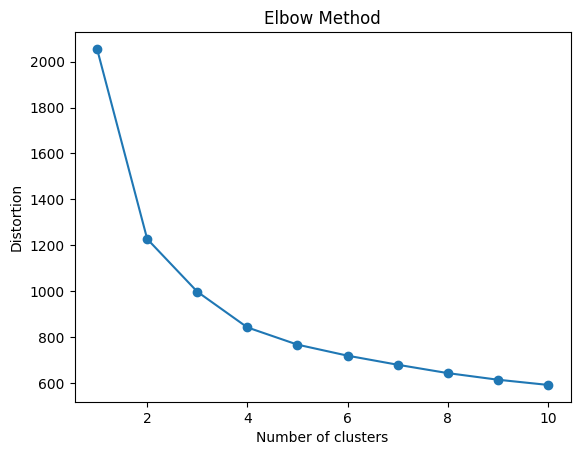

In [47]:
plt.plot(range(1, 11), distortions, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Distortion')
plt.title('Elbow Method')
plt.show()

5 Looks to be a good amount of clusters in this instance. Not only does the elbow curve start to slow down when it comes to how much it is decreasing, but it makes sense when it comes to the distribution that I am seeing in the data. 2 of the clusters are now growth categories with different densities (high/low), one is a uncertain category, and the last 2 are decreasing growth categories with different densities (high/low). I have reran the model with 5 clusters used.

Encoding

In [48]:
X_train

,STATE,pop_total_2010,housing_occupied_2010,housing_vacant_2010,housing_owner_occ_2010,housing_renter_occ_2010,age_under5_2010,age_5to9_2010,age_10to14_2010,age_15to17_2010,...,race_hispwhite_2010,race_hispblack_2010,race_hispaian_2010,race_hispapi_2010,race_hispother_2010,race_hisptwo_2010,land_area_sqkm,density_perkm2,settlement_type,cluster
32540,Massachusetts,2149,778,31,691,87,91,145,189,102,...,61,2,0,0,16,13,5.484847,391.806736,suburban,1
13546,Connecticut,1969,630,263,161,469,188,155,179,130,...,327,73,6,0,480,53,0.486841,4044.441614,urban,1
58794,Rhode Island,4665,1862,984,1611,251,222,259,292,177,...,45,2,8,0,22,11,69.963764,66.677373,rural,2
29464,Maine,2708,1175,55,954,221,137,136,143,96,...,11,2,0,0,8,3,26.187744,103.407151,suburban,3
29626,Maine,6656,2299,179,1558,741,252,188,261,157,...,80,4,1,1,31,9,24.078469,276.429535,suburban,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29724,Maine,4541,1914,796,1660,254,228,266,228,168,...,30,0,1,1,4,6,159.086874,28.544153,rural,2
29760,Maine,2313,1101,732,883,218,107,99,119,73,...,15,1,0,0,4,2,295.220586,7.834819,rural,3
31333,Massachusetts,4472,1796,160,596,1200,381,317,313,197,...,214,53,2,2,209,70,1.937254,2308.422127,urban,4
29485,Maine,2069,958,548,782,176,90,110,113,61,...,7,1,0,0,0,0,578.670229,3.575439,rural,1


In [49]:
#OneHotEncoding the categorical
preprocessor=ColumnTransformer(
  transformers=[
      ('cat',OneHotEncoder(),['settlement_type', 'STATE','cluster'])],
      remainder=MinMaxScaler()

)

Two classifiers

Logistic Regression

In [50]:

model = Pipeline([
    ('prep', preprocessor),
    ('lr', LogisticRegression(random_state=42, solver='liblinear'))
])

In [51]:
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [52]:
print(confusion_matrix(y_test,y_pred))

[[ 64 132]
 [ 38 439]]


In [53]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.63      0.33      0.43       196
           1       0.77      0.92      0.84       477

    accuracy                           0.75       673
   macro avg       0.70      0.62      0.63       673
weighted avg       0.73      0.75      0.72       673



Decision Tree

In [54]:
model1 = Pipeline([
    ("prep", preprocessor),
    ("clf", DecisionTreeClassifier(max_depth=12, min_samples_leaf=18))
])

In [55]:
model1.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('prep',
                 ColumnTransformer(remainder=MinMaxScaler(),
                                   transformers=[('cat', OneHotEncoder(),
                                                  ['settlement_type', 'STATE',
                                                   'cluster'])])),
                ('clf',
                 DecisionTreeClassifier(max_depth=12, min_samples_leaf=18))])

In [56]:
y_pred1 = model1.predict(X_test)

In [57]:
print(confusion_matrix(y_test,y_pred1))

[[ 74 122]
 [ 80 397]]


In [58]:
print(classification_report(y_test, y_pred1))


              precision    recall  f1-score   support

           0       0.48      0.38      0.42       196
           1       0.76      0.83      0.80       477

    accuracy                           0.70       673
   macro avg       0.62      0.60      0.61       673
weighted avg       0.68      0.70      0.69       673



Rerunning Without Clusters

In [59]:
X_train_no_cluster=X_train.drop(columns=['cluster'])
X_test_no_cluster=X_test.drop(columns=['cluster'])

Linear Regression

In [60]:
# Define a preprocessor specifically for the 'no cluster' scenario
preprocessor_no_cluster = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(), ['settlement_type', 'STATE'])
    ],
    remainder=MinMaxScaler()
)

model2 = Pipeline([
    ('prep', preprocessor_no_cluster),
    ('lr', LogisticRegression(random_state=42, solver='liblinear'))
])

In [61]:


model2.fit(X_train_no_cluster, y_train)

y_pred2 = model2.predict(X_test_no_cluster)

In [62]:
print(confusion_matrix(y_test,y_pred2))

[[ 66 130]
 [ 37 440]]


In [63]:
print(classification_report(y_test, y_pred2))


              precision    recall  f1-score   support

           0       0.64      0.34      0.44       196
           1       0.77      0.92      0.84       477

    accuracy                           0.75       673
   macro avg       0.71      0.63      0.64       673
weighted avg       0.73      0.75      0.72       673



Decision Tree

In [64]:
model3 = Pipeline([
    ("prep", preprocessor_no_cluster),
    ("clf", DecisionTreeClassifier(max_depth=12, min_samples_leaf=18))
])

In [65]:
model3.fit(X_train_no_cluster, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('prep',
                 ColumnTransformer(remainder=MinMaxScaler(),
                                   transformers=[('cat', OneHotEncoder(),
                                                  ['settlement_type',
                                                   'STATE'])])),
                ('clf',
                 DecisionTreeClassifier(max_depth=12, min_samples_leaf=18))])

In [66]:
y_pred3 = model3.predict(X_test_no_cluster)

In [67]:
print(confusion_matrix(y_test,y_pred3))

[[ 68 128]
 [ 76 401]]


In [68]:
print(classification_report(y_test, y_pred3))


              precision    recall  f1-score   support

           0       0.47      0.35      0.40       196
           1       0.76      0.84      0.80       477

    accuracy                           0.70       673
   macro avg       0.62      0.59      0.60       673
weighted avg       0.67      0.70      0.68       673



To quote what you told us on page 9 when talking about clusters "a clean 'it did not help the forest' result is fully acceptable"


Both models basically didn't change at all with the removal of the clusters. There was an effect though. The exact numbers in the confusion matrix are all different by about 1 - 4. It effected the guesses in some way, but for the guesses, it looks like it was looking at other factors than just the cluster when it came to decisions. Density seemed to be extremely relevant without doing any major analysis.


My best model is the unclustered logistic Regression model so that is what I will be carrying forward.

#Phase 5[e]: [e]valuation

With Clusters

Logistic Regression

In [69]:
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test, y_pred))


[[ 64 132]
 [ 38 439]]
              precision    recall  f1-score   support

           0       0.63      0.33      0.43       196
           1       0.77      0.92      0.84       477

    accuracy                           0.75       673
   macro avg       0.70      0.62      0.63       673
weighted avg       0.73      0.75      0.72       673



Precision: .77

Recall: .92

Accuracy: .75

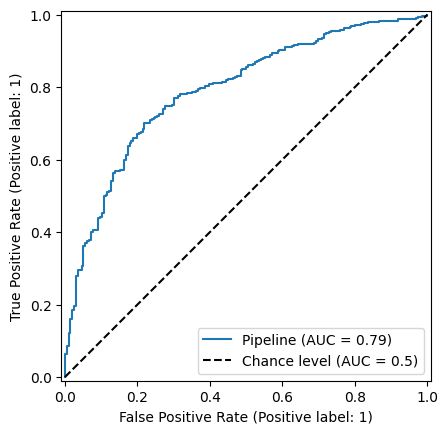

In [70]:

RocCurveDisplay.from_estimator(model, X_test, y_test,plot_chance_level=True)


In [71]:
roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])

np.float64(0.7913832199546486)

Decision Tree

In [72]:
print(confusion_matrix(y_test,y_pred1))
print(classification_report(y_test, y_pred1))

[[ 74 122]
 [ 80 397]]
              precision    recall  f1-score   support

           0       0.48      0.38      0.42       196
           1       0.76      0.83      0.80       477

    accuracy                           0.70       673
   macro avg       0.62      0.60      0.61       673
weighted avg       0.68      0.70      0.69       673



Precision: .76

Recall: .83

Accuracy: .70

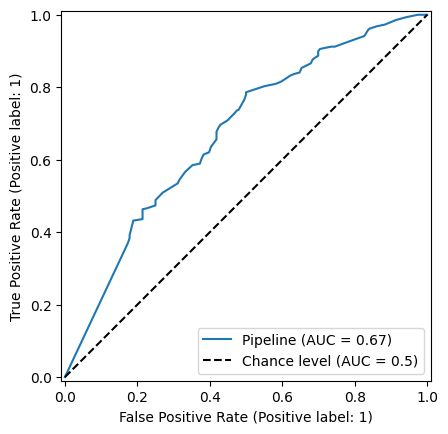

In [73]:

RocCurveDisplay.from_estimator(model1, X_test, y_test,plot_chance_level=True)


In [74]:
roc_auc_score(y_test, model1.predict_proba(X_test)[:, 1])

np.float64(0.6720147178368203)

Without Clusters

Logistic Regression

In [75]:
print(confusion_matrix(y_test,y_pred2))
print(classification_report(y_test, y_pred2))


[[ 66 130]
 [ 37 440]]
              precision    recall  f1-score   support

           0       0.64      0.34      0.44       196
           1       0.77      0.92      0.84       477

    accuracy                           0.75       673
   macro avg       0.71      0.63      0.64       673
weighted avg       0.73      0.75      0.72       673



Precision: .77

Recall: .92

Accuracy: .75

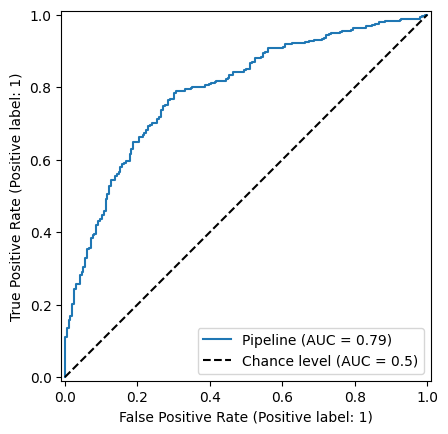

In [76]:
RocCurveDisplay.from_estimator(model2, X_test_no_cluster, y_test,plot_chance_level=True)


In [77]:
roc_auc_score(y_test, model2.predict_proba(X_test_no_cluster)[:, 1])

np.float64(0.790848414837633)

Decision Tree

In [78]:
print(confusion_matrix(y_test,y_pred3))
print(classification_report(y_test, y_pred3))

[[ 68 128]
 [ 76 401]]
              precision    recall  f1-score   support

           0       0.47      0.35      0.40       196
           1       0.76      0.84      0.80       477

    accuracy                           0.70       673
   macro avg       0.62      0.59      0.60       673
weighted avg       0.67      0.70      0.68       673



Precision: .76

Recall: .84 (it went up by .01!)

Accuracy: .70

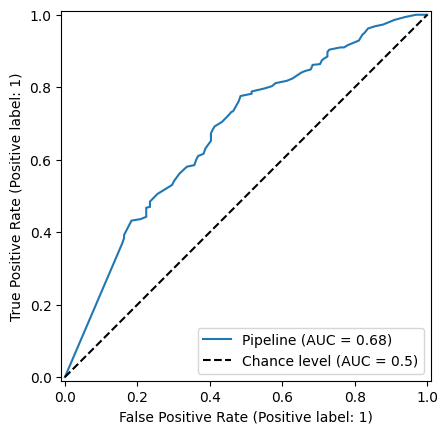

In [79]:
RocCurveDisplay.from_estimator(model3, X_test_no_cluster, y_test,plot_chance_level=True)


In [80]:
roc_auc_score(y_test, model3.predict_proba(X_test_no_cluster)[:, 1])

np.float64(0.6762557224147522)

Ablation: Both models basically didn't change at all with the removal of the clusters. There was an effect though. The exact numbers in the confusion matrix are all different by about 1 - 4. It effected the guesses in some way, but for the guesses, it looks like it was looking at other factors than just the cluster when it came to decisions. The AUC for the unclustered logistic regression by 10% (and if I am being honest, sorry grade, I got no idea why

¯\\_(ツ)_/¯

)


Most Important Metric for neighborhood growth:

Precision

In this example, we are a data scientist working for the US. Expecting that people will move into an area over time, someone (government probably) invests a lot of money to put in things that will help the people they expect to move in. But they never do. It is a waste of resources.


I would understand saying recall here. If a lot of people move into an area, but they don't really have a lot of support because no one predicted that they would move there, there would be upset people and uncapitalized opportunities. Additionally, there would be the threat of running out of existing resources because too many people are moving into an area that no one expected. I just find this less likely than precision. It is hard to think of a situation in which a lot of people move into an area that can't really support it, and if it's literally a  place no one lives with no foundation, I don't know why a group of people are all moving there at once.

Precision feels like a more practical threat here.

Thinking about that, my best model is the unclustered logistic Regression model so that is what I will be carrying forward. It has the highest precision (and AUC as a bonus over the clustered version). So I'll be using model2.

In [81]:
#Gemini helped with code (got this from previous Homework)
#Most Important Features

clf_feature_importances = model3.named_steps['clf'].feature_importances_

feature_names_out = model3.named_steps['prep'].get_feature_names_out()

feature_importance_series = pd.Series(clf_feature_importances, index=feature_names_out)

sorted_feature_importance = feature_importance_series.sort_values(ascending=False)

print("Ranked Feature Importances:")
print(sorted_feature_importance)

Ranked Feature Importances:
cat__STATE_Massachusetts              0.175753
remainder__race_nhapi_2010            0.111841
remainder__density_perkm2             0.085033
remainder__age_30to34_2010            0.057421
cat__STATE_Connecticut                0.048346
remainder__race_nhaian_2010           0.046564
remainder__race_nhother_2010          0.046332
remainder__age_20_2010                0.041380
remainder__housing_renter_occ_2010    0.035027
remainder__race_hispother_2010        0.033908
remainder__age_75to79_2010            0.032484
remainder__housing_vacant_2010        0.030208
remainder__race_hisptwo_2010          0.030028
remainder__age_15to17_2010            0.026681
remainder__pop_total_2010             0.022896
remainder__housing_occupied_2010      0.017223
remainder__age_18to19_2010            0.016809
remainder__race_hispwhite_2010        0.016618
remainder__age_10to14_2010            0.016172
remainder__age_80to84_2010            0.013058
remainder__age_35to39_2010      

Intrepretation: It seems that the largest feature that the model was deciding on was Massachusetts. It weighed that the highest when it came to deciding. I imagine that if I looked at most of the Massachusetts data with the growth listed with it, I imagine that it would skew pretty heavily.

The second most important feature was a hispanic race. I imagine that this is a predictor because maybe certain areas having growing hispanic populations that the data was picking up on, specifically this one.

Just eye balling the data, I had noticed that density was a pretty key predictor. I imagine that this is because it is an indicator of maybe a more urban environment. Urban environments tend to grow and grow noticably. Whether that is considered leakage or not, I don't know.

The first age related job is 30-34, so I think that it could have something to do with people moving to this area for business opportunities maybe.

Leakage:

If your data contains leakage, you risk containinating your model in a way that makes it so it will not accurately predict in an honest way. It is being fed too much of the data, and answers are basically being given to the model. It hasn't actually found a way predict, it's just using the answers it already has.

The ways I controlled for the leakage was making sure I wasn't training the model on something that could risk the legitmancy of the model as a whole. This means seperating things like growth, growth_pct, and population_2020 out of the model before giving it the training data. My recall, precision, and accuracy aren't too high so I actually think the model turned out well here.  

#Phase 6[f]: Deployment

In [81]:
#Rerunning the code with the 2020 data
#Using the same model however

In [82]:
ft

,GISJOIN,STATE,STATEA,COUNTY,COUNTYA,TRACTA,pop_total_2020,housing_occupied_2020,housing_vacant_2020,housing_owner_occ_2020,...,race_nhtwo_2020,race_hispwhite_2020,race_hispblack_2020,race_hispaian_2020,race_hispapi_2020,race_hispother_2020,race_hisptwo_2020,land_area_sqkm,density_perkm2,settlement_type
0,G0100010020100,Alabama,1,Autauga County,1,20100,1775.0,646.0,73.0,509.0,...,91.0,13.0,0.0,0.0,3.0,29.0,31.0,9.809944,180.938851,suburban
1,G0100010020200,Alabama,1,Autauga County,1,20200,2055.0,723.0,83.0,427.0,...,60.0,8.0,6.0,0.0,3.0,15.0,11.0,3.340505,615.176448,suburban
2,G0100010020300,Alabama,1,Autauga County,1,20300,3216.0,1291.0,100.0,907.0,...,142.0,24.0,0.0,5.0,1.0,35.0,35.0,5.349274,601.203079,suburban
3,G0100010020400,Alabama,1,Autauga County,1,20400,4246.0,1707.0,105.0,1315.0,...,191.0,56.0,7.0,0.0,0.0,33.0,62.0,6.382705,665.235194,suburban
4,G0100010020500,Alabama,1,Autauga County,1,20500,11222.0,4573.0,187.0,2409.0,...,482.0,108.0,36.0,10.0,2.0,106.0,198.0,11.397725,984.582450,suburban
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73052,G5600430000200,Wyoming,56,Washakie County,43,200,3139.0,1292.0,257.0,990.0,...,85.0,97.0,0.0,10.0,0.0,84.0,103.0,5780.555622,0.543027,rural
73053,G5600430000301,Wyoming,56,Washakie County,43,301,2339.0,1034.0,197.0,694.0,...,80.0,150.0,0.0,19.0,0.0,145.0,149.0,1.993201,1173.489277,urban
73054,G5600430000302,Wyoming,56,Washakie County,43,302,2207.0,945.0,124.0,714.0,...,48.0,85.0,0.0,3.0,2.0,116.0,107.0,15.265794,144.571583,suburban
73055,G5600450951100,Wyoming,56,Weston County,45,951100,3336.0,1257.0,272.0,1070.0,...,93.0,49.0,0.0,1.0,0.0,76.0,38.0,6100.218845,0.546866,rural


In [83]:
#Just the 6 states now
ft = sd[sd['STATE'].isin(ne_states)]

print(f"Original Amount of Tracts in Data: {ft.shape}")
print(f"Filtered Amount of Tracks: {ft.shape}")
display(ft.head(10))

Original Amount of Tracts in Data: (3392, 49)
Filtered Amount of Tracks: (3392, 49)


,GISJOIN,STATE,STATEA,COUNTY,COUNTYA,TRACTA,pop_total_2010,housing_occupied_2010,housing_vacant_2010,housing_owner_occ_2010,...,race_hispwhite_2010,race_hispblack_2010,race_hispaian_2010,race_hispapi_2010,race_hispother_2010,race_hisptwo_2010,pop_total_2020,land_area_sqkm,density_perkm2,settlement_type
12866,G0900010010101,Connecticut,9,Fairfield County,1,10101,4476,1514,264,1278,...,163,2,1,2,23,6,4401.0,32.747439,136.682444,suburban
12867,G0900010010102,Connecticut,9,Fairfield County,1,10102,4330,1418,235,1276,...,187,3,1,1,17,7,4276.0,32.581821,132.896194,suburban
12868,G0900010010201,Connecticut,9,Fairfield County,1,10201,3421,1030,126,848,...,153,0,0,2,31,3,3395.0,11.253122,304.004524,suburban
12869,G0900010010202,Connecticut,9,Fairfield County,1,10202,5359,1876,128,1441,...,346,3,3,0,47,19,5523.0,9.741256,550.134397,suburban
12870,G0900010010300,Connecticut,9,Fairfield County,1,10300,4010,1451,264,1057,...,144,2,0,0,14,12,4305.0,9.607989,417.361011,suburban
12871,G0900010010400,Connecticut,9,Fairfield County,1,10400,5290,2163,180,1493,...,382,11,13,1,142,50,5716.0,2.698094,1960.643328,urban
12872,G0900010010500,Connecticut,9,Fairfield County,1,10500,5494,2408,316,669,...,736,21,3,12,323,78,6005.0,1.816656,3024.237940,urban
12873,G0900010010600,Connecticut,9,Fairfield County,1,10600,1845,1085,167,406,...,179,6,5,1,24,20,1884.0,0.883182,2089.037141,urban
12874,G0900010010700,Connecticut,9,Fairfield County,1,10700,3579,1702,171,864,...,366,7,1,0,82,14,3573.0,1.855238,1929.132543,urban
12875,G0900010010800,Connecticut,9,Fairfield County,1,10800,3388,1350,84,951,...,173,5,0,0,30,10,3516.0,1.945195,1741.727693,urban


In [84]:
#Getting rid of random collumns
ft.drop(columns=['GISJOIN', 'STATEA', 'COUNTY', 'COUNTYA', 'TRACTA'])

,STATE,pop_total_2010,housing_occupied_2010,housing_vacant_2010,housing_owner_occ_2010,housing_renter_occ_2010,age_under5_2010,age_5to9_2010,age_10to14_2010,age_15to17_2010,...,race_hispwhite_2010,race_hispblack_2010,race_hispaian_2010,race_hispapi_2010,race_hispother_2010,race_hisptwo_2010,pop_total_2020,land_area_sqkm,density_perkm2,settlement_type
12866,Connecticut,4476,1514,264,1278,236,206,302,367,230,...,163,2,1,2,23,6,4401.00,32.747439,136.682444,suburban
12867,Connecticut,4330,1418,235,1276,142,187,398,453,310,...,187,3,1,1,17,7,4276.00,32.581821,132.896194,suburban
12868,Connecticut,3421,1030,126,848,182,164,297,350,230,...,153,0,0,2,31,3,3395.00,11.253122,304.004524,suburban
12869,Connecticut,5359,1876,128,1441,435,350,469,450,261,...,346,3,3,0,47,19,5523.00,9.741256,550.134397,suburban
12870,Connecticut,4010,1451,264,1057,394,212,302,391,248,...,144,2,0,0,14,12,4305.00,9.607989,417.361011,suburban
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67662,Vermont,1611,688,377,569,119,61,80,110,71,...,21,0,0,0,2,4,1621.02,114.280649,14.096875,rural
67663,Vermont,1963,930,2355,611,319,76,82,97,74,...,12,0,0,1,0,2,2172.00,91.111072,21.545131,rural
67664,Vermont,4187,1882,884,1440,442,168,217,241,154,...,25,0,0,0,3,9,4196.02,309.163886,13.542979,rural
67665,Vermont,5075,2178,245,1440,738,329,297,282,195,...,57,0,2,1,12,11,5001.35,69.917019,72.586047,rural


In [85]:
settlement_count1 = ft['settlement_type'].value_counts()
print(settlement_count1)
#Slightly more urban settlements than before (3 more), 2 more suburban

settlement_type
urban       1385
suburban    1303
rural        682
Name: count, dtype: int64


In [86]:
#Missing data (from gemini from earlier)
missing_data_counts5 = ft.isnull().sum()

# Display columns with missing data (if any)
# Filtering to show only columns with at least one missing value
missing_data_counts = missing_data_counts5[missing_data_counts5 > 0]

if not missing_data_counts1.empty:
    print("Count of missing data for each column:")
    display(missing_data_counts)
else:
    print("No missing data found.")

Count of missing data for each column:


,0
land_area_sqkm,21
density_perkm2,22
settlement_type,22


In [87]:
#making sure all waterland is removed by setting nans in settlement to 0
ft['settlement_type'] = ft['settlement_type'].fillna(0)

/tmp/ipykernel_8448/3042496762.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ft['settlement_type'] = ft['settlement_type'].fillna(0)


In [88]:
#Rewrote gemini code from earlier to work for this.
#Dropping when settlement type is 0 because it is waterland

initial_rows_st1 = ne.shape[0]
ft = ft[ft['settlement_type'] != 0]
print(f"Dropped {initial_rows_st1 - ft.shape[0]} rows where settlement_type was 0.")
print(f"New number of rows in 'ft' DataFrame: {ft.shape[0]}")

Dropped -5 rows where settlement_type was 0.
New number of rows in 'ft' DataFrame: 3370


In [89]:
#Missing data (from gemini from earlier)
missing_data_counts5 = ft.isnull().sum()

# Display columns with missing data (if any)
# Filtering to show only columns with at least one missing value
missing_data_counts = missing_data_counts5[missing_data_counts5 > 0]

if not missing_data_counts1.empty:
    print("Count of missing data for each column:")
    display(missing_data_counts)
else:
    print("No missing data found.")

#Zero now

Count of missing data for each column:


,0


In [90]:
#Asked Gemini for help, it said that this would work
#This should run all of the preprocessors, processors, and the model
ft['predicted_growth'] = model2.predict(ft)

# Display the forecast DataFrame with the predicted growth
display(ft.head())

,GISJOIN,STATE,STATEA,COUNTY,COUNTYA,TRACTA,pop_total_2010,housing_occupied_2010,housing_vacant_2010,housing_owner_occ_2010,...,race_hispblack_2010,race_hispaian_2010,race_hispapi_2010,race_hispother_2010,race_hisptwo_2010,pop_total_2020,land_area_sqkm,density_perkm2,settlement_type,predicted_growth
12866,G0900010010101,Connecticut,9,Fairfield County,1,10101,4476,1514,264,1278,...,2,1,2,23,6,4401.0,32.747439,136.682444,suburban,0
12867,G0900010010102,Connecticut,9,Fairfield County,1,10102,4330,1418,235,1276,...,3,1,1,17,7,4276.0,32.581821,132.896194,suburban,0
12868,G0900010010201,Connecticut,9,Fairfield County,1,10201,3421,1030,126,848,...,0,0,2,31,3,3395.0,11.253122,304.004524,suburban,0
12869,G0900010010202,Connecticut,9,Fairfield County,1,10202,5359,1876,128,1441,...,3,3,0,47,19,5523.0,9.741256,550.134397,suburban,1
12870,G0900010010300,Connecticut,9,Fairfield County,1,10300,4010,1451,264,1057,...,2,0,0,14,12,4305.0,9.607989,417.361011,suburban,0


In [91]:
pred_growth_by_state = ft.groupby('STATE')['predicted_growth'].value_counts()
print(pred_growth_by_state)

STATE          predicted_growth
Connecticut    1                    476
               0                    353
Maine          1                    286
               0                     65
Massachusetts  1                   1468
               0                      3
New Hampshire  1                    292
               0                      2
Rhode Island   1                    240
               0                      1
Vermont        1                    124
               0                     60
Name: count, dtype: int64


Summary:

For Connecticut, the model predicts that 476 of the tracts will grow, while 353 will not.

For Maine, the model predicts that 286 of the tracts will grow, while 65 will not.

For Massachusetts, the model predicts that 1468 of the tracts will grow, while 3 will not.

For New Hampshire, the model predicts that 292 of the tracts will grow, while 2 will not.

For Rhode Island, the model predicts that 240 of the tracts will grow, while 1 will not.

For Vermont, the model predicts that 124 of the tracts will grow, while 60 will not.





My reccomendation to the Department of Economic Developement is to focus on the states Massachusetts, New Hampshire, and Rhode Island since they show the most predicted growth. Some of the large factors that have been driving this growth are density of the area (per km^2), the hispanic races in the area, and the ages of the people in the area (specifically 30-34 year olds, which could indicate that something is drawing those people here. Maybe something like job opportunities).

When it comes to what the model is good at, I think that it likely accurately guessed the growths of states like Maine, Vermont, and Connecticut. I feel like these feel like a natural split, and feel believable for predicted grwoth.

 I am questioning the others. Since states are included, it feels like the model my have over weighed the states impact when it is deciding. For something like Massachusetts, it feels more like it saw Massachusetts and assigned it to growth rather than considering everything. These feel like they only make sense if population is literally growing everywhere (I guess it could be though).

 Additionally, one risk is that this is ultimately a recall model, even if I said the focus should be on precision. This was the best model I had for precision, but we still see that it is prioritizing recall over precision. If the issues with precision become too much to handle, it may be worth revisiting the models and finding one that yields a high precision, rather than recall.